In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pydeseq2.default_inference
import pydeseq2.ds
import pydeseq2.dds
import Go_tools

# Jump to top

In [2]:
###Define Thresholds
rare_species_definition_threshold = 0.1
rare_species_abundance_threshold = 9.5
expressed_gene_reads_threshold = 2000
number_of_samples_expressed_in_threshold = 21

In [3]:
# 5 good 60\
# 6 34
#7 good 32
#7.5 bad
#8 meh 18
#8.5 good 48
#9 good 54
#9.5 good 59


In [4]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
raw_transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_for_norm.csv",
    index_col=0,
)

## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome
trimmed_raw_transcriptome = raw_transcriptome.loc[trimmed_metadata.index]


In [5]:
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [6]:
trimmed_raw_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,19,5,0,26,84,0,0,154,0,118,...,0,45,0,1,0,0,15,0,0,3
A2450525897_n01_LICRNA01_B01,30,42,0,31,125,0,0,412,0,218,...,0,125,0,1,0,0,7,0,0,11
A2450525897_n01_LICRNA01_C01,30,43,0,0,74,0,0,126,0,103,...,7,131,0,0,0,0,1,0,0,2
A2450525897_n01_LICRNA01_E01,19,27,0,22,41,0,0,135,0,89,...,0,44,0,0,0,0,3,0,0,5
A2450525897_n01_LICRNA01_F01,11,32,0,9,126,0,0,177,0,135,...,0,235,0,0,0,0,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0,105,0,120,161,0,0,366,0,29,...,0,55,13,5,0,0,2,0,11,35
A2534491401_n01_LICRNA05_E12,0,23,0,26,166,0,0,298,0,381,...,0,89,1,16,0,0,50,0,0,23
A2534491401_n01_LICRNA05_F12,9,78,0,26,294,0,0,474,0,700,...,0,93,0,7,0,0,0,0,0,1


In [7]:
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,383610.0,D,12,6510475.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00
A2534491401_n01_LICRNA05_E12,E12,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,451686.0,E,12,6178604.0,Circadian Experiment 1,February,102,2024-02-11 04:00:00
A2534491401_n01_LICRNA05_F12,F12,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,360911.0,F,12,7035335.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00


In [8]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
long_term_microbiome

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1,LIC522,Circadian Experiment 1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5,LIC159,Long Term
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8,LIC452,Circadian Experiment 1
4,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8,LIC452,Circadian Experiment 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15326,LIC028,plant,t03,11/14/23,8:00,LIC_01,13,LIC028,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Modestobacter,Modestobacter muralis,0.5,LIC028,Long Term
15327,LIC631,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC631,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas subvibrioides,0.5,LIC631,Circadian Experiment 2
15328,LIC712,plant,c2_t10,3/3/24,8:00,LICCIRC_04,123,LIC712,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Klenkia,Klenkia sp001424455,0.5,LIC712,Circadian Experiment 2
15329,LIC629,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC629,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Agrobacterium,Agrobacterium larrymoorei,0.5,LIC629,Circadian Experiment 2


In [9]:
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [10]:
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,383610.0,D,12,6510475.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00
A2534491401_n01_LICRNA05_E12,E12,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,451686.0,E,12,6178604.0,Circadian Experiment 1,February,102,2024-02-11 04:00:00
A2534491401_n01_LICRNA05_F12,F12,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,360911.0,F,12,7035335.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00


In [11]:
species_abundance_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/species_core_results.csv"
)
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True
...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False
275,Telluria timonae,1,10.800000,10.80,0.002688,False
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False


In [12]:
### Note 372 total samples

In [13]:
species_abundance_table["rare"] = False
species_abundance_table.loc[
    species_abundance_table["n_samples_present"] <= 37, "rare"
] = True
species_abundance_table

,Species,n_samples_present,mean_abundance_present,median_abundance_present,prevalence,core,rare
0,Kordiimonas sp002401685,372,3.661053,3.30,1.000000,True,False
1,Sphingomonas_L_486704 sp000786205,372,17.954211,15.90,1.000000,True,False
2,Rhodoferax_C aquaticus,370,4.407143,3.70,0.994624,True,False
3,Neorhizobium soli,366,3.855080,2.25,0.983871,True,False
4,Klenkia sp001424455,363,3.581402,2.70,0.975806,True,False
...,...,...,...,...,...,...,...
274,Tardiphaga robiniae,1,0.500000,0.50,0.002688,False,True
275,Telluria timonae,1,10.800000,10.80,0.002688,False,True
276,UBA4416 sp002420145,1,0.700000,0.70,0.002688,False,True
277,Umezawaea tangerina,1,1.100000,1.10,0.002688,False,True


In [14]:
list_of_rare_species = species_abundance_table.loc[
    species_abundance_table["rare"] == True, "Species"
].tolist()
list_of_core_species = species_abundance_table.loc[
    species_abundance_table["core"] == True, "Species"
].tolist()
list_of_rare_species

['Bradyrhizobium sp000938255',
 'Noviherbaspirillum_A_568104 psychrotolerans',
 'Brevundimonas huaxiensis',
 'Mycobacterium paragordonae',
 'Aeromicrobium sp001426485',
 'Marmoricola_A_392027 sp001424755',
 'Flavobacterium sangjuense',
 'Herbaspirillum robiniae',
 'Hylemonella sp001432305',
 'Telluria mixta',
 'Undibacterium arcticum',
 'Brevundimonas sp001424025',
 'Herminiimonas arsenicoxydans',
 'Amnibacterium kyonggiense',
 'Patulibacter minatonensis',
 'Aquabacterium_A_592457 parvum',
 'Chioneia frigida',
 'Curtobacterium sp001422205',
 'Kineosporia rhamnosa',
 'Pseudonocardia hierapolitana',
 'Nakamurella panacisegetis',
 'Curvibacter gracilis',
 'Agrobacterium rubi',
 'Nocardioides_A_392796 ginsengisegetis',
 'Pseudoduganella namucuonensis',
 'Pseudomonas_E_647464 rhizosphaerae',
 'Actinoplanes rectilineatus',
 'Microbacterium_A_383321 testaceum_F',
 'Actinoplanes globisporus',
 'Herbaspirillum seropedicae',
 'Methylophilus methylotrophus',
 'Pseudomonas_E_647626 sp900573885',
 

In [15]:
list_of_core_species

['Kordiimonas sp002401685',
 'Sphingomonas_L_486704 sp000786205',
 'Rhodoferax_C aquaticus',
 'Neorhizobium soli',
 'Klenkia sp001424455',
 'Massilia atriviolacea',
 'Variovorax paradoxus_C',
 'Flavobacterium chilense',
 'Sphingomonas_L_486704 taxi',
 'Frigoribacterium sp001424645']

In [16]:
microbiome_abundance

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16888,t03_soil,soil,t03,11/14/23,8:00,LIC_01,13,t03_soil,d__Bacteria,Bacillota_I,Bacilli_A,Bacillales_B_306089,Bacillaceae_H_289398,Priestia_289346,Priestia megaterium,0.5
16889,LIC631,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC631,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas subvibrioides,0.5
16890,LIC712,plant,c2_t10,3/3/24,8:00,LICCIRC_04,123,LIC712,d__Bacteria,Actinomycetota,Actinomycetes,Mycobacteriales,Geodermatophilaceae,Klenkia,Klenkia sp001424455,0.5
16891,LIC629,plant,c2_t05,3/2/24,12:00,LICCIRC_03,122,LIC629,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Agrobacterium,Agrobacterium larrymoorei,0.5


In [17]:
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,383610.0,D,12,6510475.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00
A2534491401_n01_LICRNA05_E12,E12,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,451686.0,E,12,6178604.0,Circadian Experiment 1,February,102,2024-02-11 04:00:00
A2534491401_n01_LICRNA05_F12,F12,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,360911.0,F,12,7035335.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00


In [18]:
# For each sample, check if it has any rare species or is lacking any core species
rare_species_set = set(list_of_rare_species)
core_species_set = set(list_of_core_species)

# Get species present for each sample (using sampID from long_term_microbiome)
sample_species = long_term_microbiome.groupby("sampID")["Species"].apply(set)

# Check if sample has any rare species
has_rare_species = sample_species.apply(lambda x: len(x & rare_species_set) > 0)

# Check if sample is lacking any core species (missing at least one core species)
lacking_core_species = sample_species.apply(lambda x: not core_species_set.issubset(x))

# Total relative abundance of rare species per sample (sum of AbundR100 over rare species)
rare_abund_by_sample = (
    long_term_microbiome.loc[
        long_term_microbiome["Species"].isin(rare_species_set),
        ["sampID", "AbundR100"],
    ]
    .assign(
        AbundR100=lambda d: pd.to_numeric(d["AbundR100"], errors="coerce").fillna(
            0.0
        )  ##Junky column that just makes sure that its numeric
    )
    .groupby("sampID", sort=False)["AbundR100"]
    .sum()
    .rename("rare_species_total_abundR100")
)

# Add columns to metadata using the sampID column (not the index)
trimmed_metadata["has_rare_species"] = (
    trimmed_metadata["sampID"].map(has_rare_species).fillna(False)
)
trimmed_metadata["lacking_core_species"] = (
    trimmed_metadata["sampID"].map(lacking_core_species).fillna(True)
)
trimmed_metadata["rare_species_total_abundR100"] = (
    trimmed_metadata["sampID"].map(rare_abund_by_sample).fillna(0.0)
)

trimmed_metadata[
    [
        "sampID",
        "has_rare_species",
        "lacking_core_species",
        "rare_species_total_abundR100",
    ]
]

,sampID,has_rare_species,lacking_core_species,rare_species_total_abundR100
filename,,,,
A2450525897_n01_LICRNA01_A01,LIC001,True,False,11.7
A2450525897_n01_LICRNA01_B01,LIC002,True,True,20.8
A2450525897_n01_LICRNA01_C01,LIC003,True,False,34.0
A2450525897_n01_LICRNA01_E01,LIC005,True,True,5.3
A2450525897_n01_LICRNA01_F01,LIC006,True,True,16.0
...,...,...,...,...
A2534491401_n01_LICRNA05_D12,LIC542,True,False,16.2
A2534491401_n01_LICRNA05_E12,LIC495,True,True,38.0
A2534491401_n01_LICRNA05_F12,LIC421,True,False,8.0


In [19]:
# trimmed_metadata.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/rare_species_total_abund_generated.csv",
#     index=True,
# )

<Axes: xlabel='rare_species_total_abundR100', ylabel='Count'>

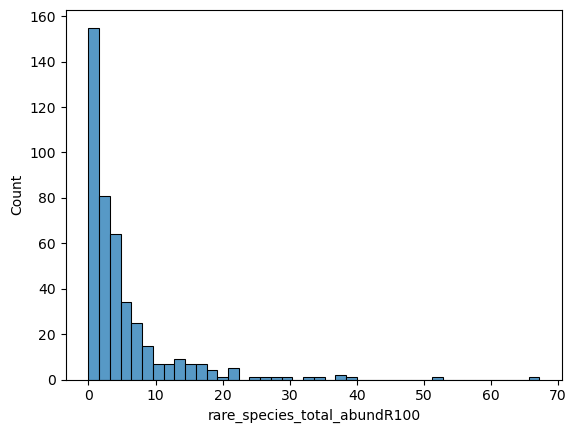

In [20]:
sns.histplot(trimmed_metadata["rare_species_total_abundR100"])

In [21]:
trimmed_raw_transcriptome.loc[:, trimmed_raw_transcriptome.sum() < 200_00]

,AT1G01010,AT1G03987,AT1G01030,AT1G03993,AT1G01046,AT1G03997,AT1G01070,AT1G04003,AT1G01110,AT1G01150,...,ArthCt114,ArthCt124,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,19,0,26,0,0,0,9,0,3,0,...,0,0,0,1,0,0,15,0,0,3
A2450525897_n01_LICRNA01_B01,30,0,31,0,0,0,0,0,15,1,...,9,0,0,1,0,0,7,0,0,11
A2450525897_n01_LICRNA01_C01,30,0,0,0,0,0,6,0,0,0,...,0,7,0,0,0,0,1,0,0,2
A2450525897_n01_LICRNA01_E01,19,0,22,0,0,0,3,0,5,0,...,0,0,0,0,0,0,3,0,0,5
A2450525897_n01_LICRNA01_F01,11,0,9,0,0,0,4,0,1,0,...,0,0,0,0,0,0,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0,0,120,0,0,0,5,0,14,0,...,0,0,13,5,0,0,2,0,11,35
A2534491401_n01_LICRNA05_E12,0,0,26,0,0,0,19,0,28,0,...,44,0,1,16,0,0,50,0,0,23
A2534491401_n01_LICRNA05_F12,9,0,26,0,0,0,83,0,49,0,...,0,0,0,7,0,0,0,0,0,1


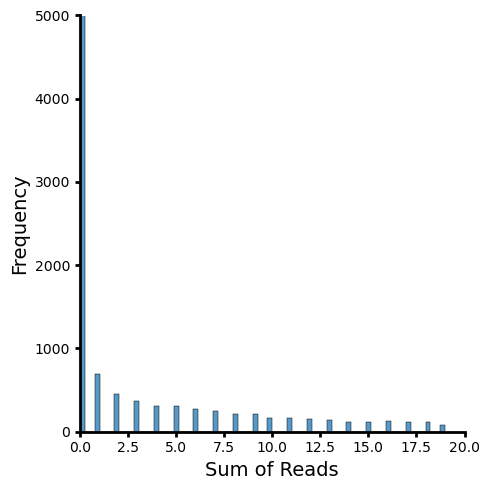

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.histplot(
    trimmed_raw_transcriptome.loc[:, trimmed_raw_transcriptome.sum() < 20].sum()
)
plt.xlabel("Sum of Reads", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xlim((0, 20))
plt.ylim((0, 5000))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [23]:
trimmed_metadata.loc[
    trimmed_metadata["rare_species_total_abundR100"] > rare_species_abundance_threshold
]

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,has_rare_species,lacking_core_species,rare_species_total_abundR100
filename,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,True,False,11.7
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,True,True,20.8
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,True,False,34.0
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00,True,True,16.0
A2450525897_n01_LICRNA01_H01,H01,LIC008,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5166151.0,178636.0,H,1,4167119.0,Long Term,November,0,2023-11-01 08:00:00,True,True,11.6
A2450525897_n01_LICRNA01_B02,B02,LIC014,plant,t02,11/7/23,8:00,LIC_01,LICRNA_01,5558289.0,378067.0,B,2,5479289.0,Long Term,November,6,2023-11-07 08:00:00,True,True,9.9
A2450525897_n01_LICRNA01_E02,E02,LIC017,plant,t02,11/7/23,8:00,LIC_01,LICRNA_01,4498762.0,394186.0,E,2,8122024.0,Long Term,November,6,2023-11-07 08:00:00,True,False,37.9
A2450525897_n01_LICRNA01_F02,F02,LIC018,plant,t02,11/7/23,8:00,LIC_01,LICRNA_01,7244532.0,258247.0,F,2,6150794.0,Long Term,November,6,2023-11-07 08:00:00,True,True,18.0
A2450525897_n01_LICRNA01_B03,B03,LIC026,plant,t03,11/14/23,8:00,LIC_01,LICRNA_01,11156787.0,496131.0,B,3,8305980.0,Long Term,November,13,2023-11-14 08:00:00,True,False,12.9


In [24]:
cleaned_raw_transcriptome = trimmed_raw_transcriptome.loc[
    :, trimmed_raw_transcriptome.sum() > expressed_gene_reads_threshold
]

cleaned_raw_transcriptome

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCp081,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCr088,ArthCp088,ArthCp083,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,19,5,26,84,154,118,9,31,314,1534,...,337,2650,0,17,659,0,45,1,15,3
A2450525897_n01_LICRNA01_B01,30,42,31,125,412,218,0,119,829,6287,...,675,7549,0,7,1392,9,125,1,7,11
A2450525897_n01_LICRNA01_C01,30,43,0,74,126,103,6,100,404,2864,...,261,3371,0,28,855,0,131,0,1,2
A2450525897_n01_LICRNA01_E01,19,27,22,41,135,89,3,56,299,3131,...,395,4594,6,10,542,0,44,0,3,5
A2450525897_n01_LICRNA01_F01,11,32,9,126,177,135,4,12,271,1782,...,371,2657,0,0,1402,0,235,0,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0,105,120,161,366,29,5,152,635,5043,...,541,7238,9,0,923,0,55,5,2,35
A2534491401_n01_LICRNA05_E12,0,23,26,166,298,381,19,198,1037,4265,...,1304,9335,0,8,868,44,89,16,50,23
A2534491401_n01_LICRNA05_F12,9,78,26,294,474,700,83,174,798,5139,...,786,4398,0,1,893,0,93,7,0,1


In [25]:
cleaned_raw_transcriptome = cleaned_raw_transcriptome.loc[
    :, (cleaned_raw_transcriptome > 1).sum() > number_of_samples_expressed_in_threshold
]

In [26]:
cleaned_raw_transcriptome

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCp081,Arthcp087,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCr088,ArthCp088,ArthCp083,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,19,5,26,84,154,118,9,31,314,1534,...,337,2650,0,17,659,0,45,1,15,3
A2450525897_n01_LICRNA01_B01,30,42,31,125,412,218,0,119,829,6287,...,675,7549,0,7,1392,9,125,1,7,11
A2450525897_n01_LICRNA01_C01,30,43,0,74,126,103,6,100,404,2864,...,261,3371,0,28,855,0,131,0,1,2
A2450525897_n01_LICRNA01_E01,19,27,22,41,135,89,3,56,299,3131,...,395,4594,6,10,542,0,44,0,3,5
A2450525897_n01_LICRNA01_F01,11,32,9,126,177,135,4,12,271,1782,...,371,2657,0,0,1402,0,235,0,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0,105,120,161,366,29,5,152,635,5043,...,541,7238,9,0,923,0,55,5,2,35
A2534491401_n01_LICRNA05_E12,0,23,26,166,298,381,19,198,1037,4265,...,1304,9335,0,8,868,44,89,16,50,23
A2534491401_n01_LICRNA05_F12,9,78,26,294,474,700,83,174,798,5139,...,786,4398,0,1,893,0,93,7,0,1


In [27]:
# cleaned_raw_transcriptome.to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/cleaned_raw_transcriptome.csv",
#     index=True,
# )

In [28]:
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,has_rare_species,lacking_core_species,rare_species_total_abundR100
filename,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,True,False,11.7
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,True,True,20.8
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,True,False,34.0
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00,True,True,5.3
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00,True,True,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,383610.0,D,12,6510475.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00,True,False,16.2
A2534491401_n01_LICRNA05_E12,E12,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,451686.0,E,12,6178604.0,Circadian Experiment 1,February,102,2024-02-11 04:00:00,True,True,38.0
A2534491401_n01_LICRNA05_F12,F12,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,360911.0,F,12,7035335.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00,True,False,8.0


In [29]:
trimmed_metadata["High_rare_species"] = (
    trimmed_metadata["rare_species_total_abundR100"] > rare_species_abundance_threshold
)
trimmed_metadata["High_rare_species"] = trimmed_metadata["High_rare_species"].replace(
    {True: "High", False: "Low"},
)
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,has_rare_species,lacking_core_species,rare_species_total_abundR100,High_rare_species
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,...,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00,True,False,11.7,High
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,...,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00,True,True,20.8,High
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,...,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00,True,False,34.0,High
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,...,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00,True,True,5.3,Low
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,...,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00,True,True,16.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,D12,LIC542,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_05,4303811.0,383610.0,...,12,6510475.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00,True,False,16.2,High
A2534491401_n01_LICRNA05_E12,E12,LIC495,plant,c1_t09,2/11/24,4:00,LICCIRC_02,LICRNA_05,4231836.0,451686.0,...,12,6178604.0,Circadian Experiment 1,February,102,2024-02-11 04:00:00,True,True,38.0,High
A2534491401_n01_LICRNA05_F12,F12,LIC421,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_05,4885375.0,360911.0,...,12,7035335.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00,True,False,8.0,Low


In [30]:
transcriptome_for_large_deseq = cleaned_raw_transcriptome.loc[trimmed_metadata.index]
transcriptome_for_large_deseq
metadata_for_large_deseq = trimmed_metadata[["timepoint", "High_rare_species"]]
metadata_for_large_deseq

,timepoint,High_rare_species
filename,,
A2450525897_n01_LICRNA01_A01,t01,High
A2450525897_n01_LICRNA01_B01,t01,High
A2450525897_n01_LICRNA01_C01,t01,High
A2450525897_n01_LICRNA01_E01,t01,Low
A2450525897_n01_LICRNA01_F01,t01,High
...,...,...
A2534491401_n01_LICRNA05_D12,c1_t13,High
A2534491401_n01_LICRNA05_E12,c1_t09,High
A2534491401_n01_LICRNA05_F12,c1_t04,Low


In [31]:
inference = pydeseq2.default_inference.DefaultInference(n_cpus=6)
dds = pydeseq2.dds.DeseqDataSet(
    counts=transcriptome_for_large_deseq,
    metadata=metadata_for_large_deseq,
    design="~timepoint+High_rare_species",
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)

In [32]:
dds.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.20 seconds.

Fitting dispersions...
... done in 15.81 seconds.

Fitting dispersion trend curve...
... done in 0.50 seconds.

Fitting MAP dispersions...
... done in 16.59 seconds.

Fitting LFCs...
... done in 22.54 seconds.

Calculating cook's distance...
... done in 0.48 seconds.

Replacing 18 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.12 seconds.

Fitting LFCs...
... done in 0.06 seconds.



In [33]:
ds_high_vs_low_rare_species_all_samp = pydeseq2.ds.DeseqStats(
    dds, contrast=["High_rare_species", "High", "Low"], inference=inference
)

In [34]:
ds_high_vs_low_rare_species_all_samp.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: High_rare_species High vs Low
             baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
AT1G01010    9.971025       -0.500483  0.295652 -1.692809  0.090492   NaN
AT1G01020   51.489923        0.100021  0.119316  0.838285  0.401871   NaN
AT1G01030   21.630961       -0.049287  0.167275 -0.294649  0.768262   NaN
AT1G01040  115.240723       -0.177463  0.097689 -1.816607  0.069277   NaN
AT1G01050  219.913196        0.122019  0.063747  1.914114  0.055606   NaN
...               ...             ...       ...       ...       ...   ...
ArthCt114    5.937831       -0.574775  0.395377 -1.453739  0.146019   NaN
ArthCr088  164.678025        0.191619  0.165399  1.158521  0.246651   NaN
ArthCp088   12.007465       -0.015506  0.255609 -0.060661  0.951629   NaN
ArthCp083   16.245348       -0.049594  0.214816 -0.230865  0.817419   NaN
ArthCp085  114.438604       -0.086401  0.235726 -0.366530  0.713970   NaN

[18032 rows x 6 columns]


... done in 1.87 seconds.



In [35]:
ds_high_vs_low_rare_species_all_samp.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AT1G01010,9.971025,-0.500483,0.295652,-1.692809,0.090492,NaN
AT1G01020,51.489923,0.100021,0.119316,0.838285,0.401871,NaN
AT1G01030,21.630961,-0.049287,0.167275,-0.294649,0.768262,NaN
AT1G01040,115.240723,-0.177463,0.097689,-1.816607,0.069277,NaN
AT1G01050,219.913196,0.122019,0.063747,1.914114,0.055606,NaN
...,...,...,...,...,...,...
ArthCt114,5.937831,-0.574775,0.395377,-1.453739,0.146019,NaN
ArthCr088,164.678025,0.191619,0.165399,1.158521,0.246651,NaN
ArthCp088,12.007465,-0.015506,0.255609,-0.060661,0.951629,NaN
ArthCp083,16.245348,-0.049594,0.214816,-0.230865,0.817419,NaN


In [36]:
large_deseq_results = ds_high_vs_low_rare_species_all_samp.results_df
large_deseq_padj_significant = large_deseq_results.loc[
    large_deseq_results["padj"] < 0.05
]
large_deseq_padj_significant

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AT1G02930,1583.193757,-0.515097,0.162575,-3.168358,1.533026e-03,0.041287
AT1G06680,4995.852972,0.137455,0.042458,3.237437,1.206088e-03,0.040608
AT1G09340,1265.787318,0.201590,0.049540,4.069248,4.716520e-05,0.007364
AT1G17080,660.725521,-0.244284,0.077196,-3.164473,1.553643e-03,0.041287
AT1G20340,15919.812459,0.160914,0.050806,3.167241,1.538928e-03,0.041287
AT1G27290,583.605691,-0.270795,0.087454,-3.096448,1.958544e-03,0.045657
AT1G30250,1012.510500,-0.291668,0.092791,-3.143268,1.670730e-03,0.042587
AT1G32060,2225.713801,0.149700,0.044328,3.377132,7.324590e-04,0.029536
AT1G32080,1098.685388,0.249766,0.052255,4.779714,1.755452e-06,0.001096
AT1G32470,677.145795,0.172984,0.046996,3.680787,2.325153e-04,0.018145


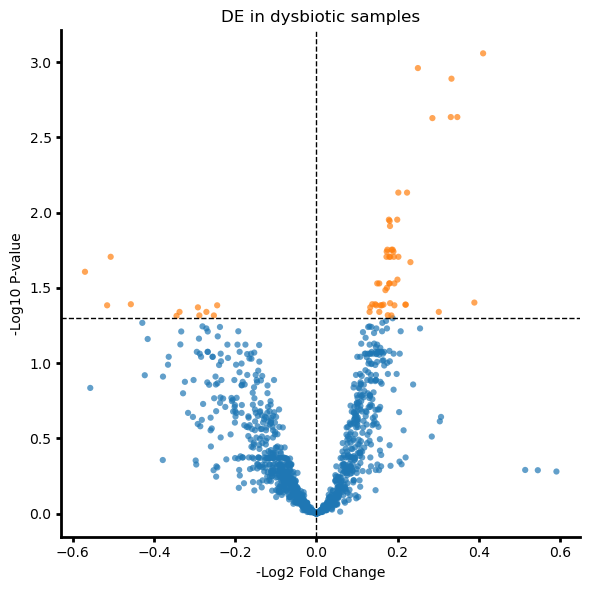

In [37]:
volcano_df = large_deseq_results[["log2FoldChange", "padj"]].copy()
volcano_df = volcano_df.replace([np.inf, -np.inf], np.nan).dropna()
volcano_df["neg_log10_padj"] = -np.log10(volcano_df["padj"].clip(lower=1e-300))
volcano_df["significant"] = volcano_df["padj"] < 0.05

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=volcano_df,
    x="log2FoldChange",
    y="neg_log10_padj",
    hue="significant",
    alpha=0.7,
    s=20,
    linewidth=0,
    ax=ax,
    legend=True,
)
ax.axhline(-np.log10(0.05), linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle="--", color="black", linewidth=1)
ax.set_title("DE in dysbiotic samples")
ax.set_xlabel("-Log2 Fold Change")
ax.set_ylabel("-Log10 P-value")

ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)

ax.spines["top"].set_color("black")
ax.spines["top"].set_linewidth(0)

# ax2.spines["right"].set_color("black")
# ax2.spines["right"].set_linewidth(2)
# ax2.spines["top"].set_color("black")
# ax2.spines["top"].set_linewidth(0)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
sns.despine()
plt.tight_layout()

In [38]:
volcano_df.sort_values(by="neg_log10_padj", ascending=False)

,log2FoldChange,padj,neg_log10_padj,significant
AT5G38420,0.410271,0.000875,3.057806,True
AT1G32080,0.249766,0.001096,2.960079,True
AT3G01500,0.332437,0.001290,2.889488,True
AT4G09650,0.330778,0.002319,2.634651,True
AT5G38410,0.346780,0.002319,2.634651,True
...,...,...,...,...
AT5G55620,0.000616,0.997836,0.000941,False
ArthCp054,0.000271,0.998406,0.000693,False
AT1G30360,-0.000367,0.998406,0.000693,False
AT1G33140,0.000128,0.999210,0.000343,False


In [39]:
volcano_df.value_counts("significant")

significant
False    1190
True       59
Name: count, dtype: int64

# Volcano

<Axes: ylabel='Count'>

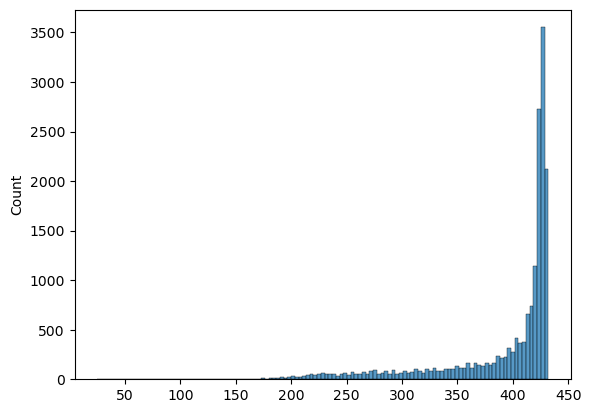

In [40]:
sns.histplot((cleaned_raw_transcriptome > 1).sum())

In [ ]:
rare_abund_by_sample

In [ ]:
cleaned_raw_transcriptome

In [ ]:
print(len(large_deseq_padj_significant))

In [44]:

background_genes_list = cleaned_raw_transcriptome.columns.tolist()

In [43]:
go_term_matrix = pd.read_csv(
    "/Users/michael/Data/Reference_data/Arabdidopsis_go_matrix_from_tair_gaf.csv",
    index_col=0,
)
go_term_matrix

,GO:0000001,GO:0000009,GO:0000012,GO:0000014,GO:0000023,GO:0000024,GO:0000025,GO:0000026,GO:0000027,GO:0000028,...,GO:2001071,GO:2001080,GO:2001141,GO:2001142,GO:2001143,GO:2001147,GO:2001227,GO:2001280,GO:2001289,GO:2001294
GeneID,,,,,,,,,,,,,,,,,,,,,
AT1G01010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01030,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1G01046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT5G67620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
large_deseq_gene_list = large_deseq_padj_significant.index.tolist()
len(large_deseq_gene_list)

59

In [45]:
large_deseq_gene_list

['AT1G02930',
 'AT1G06680',
 'AT1G09340',
 'AT1G17080',
 'AT1G20340',
 'AT1G27290',
 'AT1G30250',
 'AT1G32060',
 'AT1G32080',
 'AT1G32470',
 'AT1G32990',
 'AT1G35680',
 'AT1G54130',
 'AT1G56220',
 'AT1G60000',
 'AT1G64510',
 'AT2G21330',
 'AT2G26500',
 'AT2G27420',
 'AT2G35370',
 'AT2G38230',
 'AT2G39730',
 'AT2G43030',
 'AT2G46820',
 'AT3G01500',
 'AT3G11630',
 'AT3G12780',
 'AT3G26060',
 'AT3G26650',
 'AT3G27830',
 'AT3G54050',
 'AT3G56940',
 'AT3G60750',
 'AT3G61870',
 'AT3G62030',
 'AT3G63490',
 'AT4G02380',
 'AT4G09650',
 'AT4G21280',
 'AT4G24770',
 'AT5G01530',
 'AT5G02160',
 'AT5G04140',
 'AT5G13510',
 'AT5G13630',
 'AT5G14740',
 'AT5G28500',
 'AT5G30510',
 'AT5G35630',
 'AT5G38410',
 'AT5G38420',
 'AT5G40950',
 'AT5G54600',
 'AT5G55450',
 'AT5G64040',
 'AT5G66570',
 'ArthCp052',
 'ArthCp053',
 'ArthCp079']

In [ ]:
# pd.Series(large_deseq_gene_list).to_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/General_data/Junk_data/large_deseq_gene_list.csv",
#     index=False,
#     header=False,
# )

In [46]:
cont_tables_large = Go_tools.generate_contigency_tables(
    go_annotations=go_term_matrix,
    gene_list=large_deseq_gene_list,
    use_background_genes=True,
    background_genes=background_genes_list,
)

fishers_results_large = Go_tools.fishers_exact_on_contigency_tables(
    all_go_contigency_tables=cont_tables_large,
    original_GO_term_panda=go_term_matrix,
)

corrected_fishers_results_large = Go_tools.multi_hypothesis_correct_fishers_exact(
    fishers_results_large
)

In [47]:
corrected_fishers_results_large.sort_values("P_value").head(30)

,P_value
GO:0009941,4.195954e-29
GO:0009579,8.535910e-29
GO:0009570,5.880579e-28
GO:0009507,2.650484e-22
GO:0009535,1.020975e-21
GO:0003729,7.405524e-21
GO:0048046,1.708611e-15
GO:0010319,1.204241e-12
GO:0009534,1.310533e-09
GO:0009409,3.204126e-06


In [48]:
go_term_names = pd.read_csv(
    "/Users/michael/Data/Reference_data/goterm_names.csv", index_col=0
)
go_term_names

,x
GO:0000001,mitochondrion inheritance
GO:0000006,high-affinity zinc transmembrane transporter a...
GO:0000007,low-affinity zinc ion transmembrane transporte...
GO:0000009,"alpha-1,6-mannosyltransferase activity"
GO:0000010,heptaprenyl diphosphate synthase activity
...,...
GO:7770007,L-arginine conjugated cholate hydrolase activity
GO:7770008,L-histidine conjugated cholate hydrolase activity
GO:7770009,L-tryptophan conjugated cholate hydrolase acti...
GO:7770010,GTPBP3-MTO1 complex


In [49]:
named_large_fishers_results = corrected_fishers_results_large.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)
named_large_fishers_results.sort_values("P_value").head(40)

,P_value,x
GO:0009941,4.195954e-29,chloroplast envelope
GO:0009579,8.535910e-29,thylakoid
GO:0009570,5.880579e-28,chloroplast stroma
GO:0009507,2.650484e-22,chloroplast
GO:0009535,1.020975e-21,chloroplast thylakoid membrane
GO:0003729,7.405524e-21,mRNA binding
GO:0048046,1.708611e-15,apoplast
GO:0010319,1.204241e-12,stromule
GO:0009534,1.310533e-09,chloroplast thylakoid
GO:0009409,3.204126e-06,response to cold


In [52]:
top_40 = named_large_fishers_results.sort_values("P_value").head(40)
top_40_cleaned = top_40.drop(
    index=[
        "GO:0009535",
        "GO:0009570",
        "GO:0009507",
        "GO:0009534",
        "GO:0010319",
        "GO:0010287",
        "GO:0009543",
        "GO:0031977",
        "GO:0009658",
        "GO:0009536",
    ]
)

In [53]:
top_40_cleaned["x"] = top_40_cleaned["x"].str.capitalize()
top_40_cleaned["Neg Log P Val"] = -1 * np.log10(top_40_cleaned["P_value"])
top_40_cleaned

,P_value,x,Neg Log P Val
GO:0009941,4.195954e-29,Chloroplast envelope,28.377169
GO:0009579,8.535910e-29,Thylakoid,28.068750
GO:0003729,7.405524e-21,Mrna binding,20.130444
GO:0048046,1.708611e-15,Apoplast,14.767357
GO:0009409,3.204126e-06,Response to cold,5.494290
GO:0015979,6.664643e-06,Photosynthesis,5.176223
GO:0005829,5.332007e-05,Cytosol,4.273109
GO:0009773,6.737310e-05,Photosynthetic electron transport in photosyst...,4.171513
GO:0006412,7.925640e-05,Translation,4.100966
GO:0022626,6.208887e-04,Cytosolic ribosome,3.206986


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Chloroplast envelope'),
  Text(0, 1, 'Thylakoid'),
  Text(0, 2, 'Mrna binding'),
  Text(0, 3, 'Apoplast'),
  Text(0, 4, 'Response to cold'),
  Text(0, 5, 'Photosynthesis'),
  Text(0, 6, 'Cytosol'),
  Text(0, 7, 'Photosynthetic electron transport in photosystem i'),
  Text(0, 8, 'Translation'),
  Text(0, 9, 'Cytosolic ribosome')])

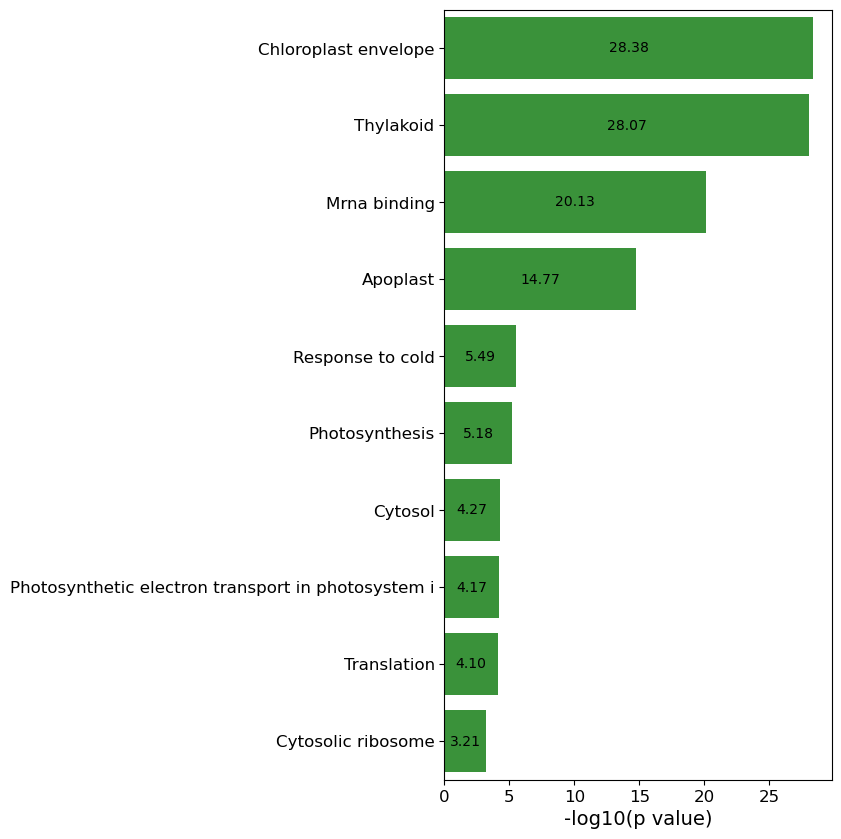

In [54]:
fig, ax = plt.subplots(figsize=(5, 10))
fig.patch.set_facecolor("white")
g = sns.barplot(
    data=top_40_cleaned.head(10), x="Neg Log P Val", y="x", color="tab:green"
)
# plt.ylabel("Euclidian Distance of Coexpressalog from Target Gene", fontsize = 15)
plt.xlabel("-log10(p value)", fontsize=14)
g.set(ylabel=None)
# sns.despine()
g.bar_label(g.containers[0], fmt="%.2f", label_type="center")

g.grid(False)
g.spines["bottom"].set_color("black")
g.spines["left"].set_color("black")
g.spines["top"].set_color("black")
g.spines["right"].set_color("black")
# ax.set_xscale('log')
# plt.xlim((-7,7))
# plt.ylim((0, 1250))
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.savefig('/data/passala/Plots_for_projects/Coexpressolog_paper_plots/updated_for_v11/go_enrichment_updated.svg')

## GO enrichment split by direction of DE

This section computes GO enrichment separately for significantly upregulated and downregulated genes, then plots the top terms for each set.

In [56]:
# Split significant genes by fold-change direction
sig_results = large_deseq_results.loc[large_deseq_results["padj"] < 0.05].copy()
upregulated_gene_list = sig_results.loc[sig_results["log2FoldChange"] > 0].index.tolist()
downregulated_gene_list = sig_results.loc[sig_results["log2FoldChange"] < 0].index.tolist()

print(f"Significant genes: {len(sig_results)}")
print(f"Upregulated genes: {len(upregulated_gene_list)}")
print(f"Downregulated genes: {len(downregulated_gene_list)}")

Significant genes: 59
Upregulated genes: 48
Downregulated genes: 11


In [61]:
downregulated_gene_list

['AT1G02930',
 'AT1G17080',
 'AT1G27290',
 'AT1G30250',
 'AT1G54130',
 'AT1G56220',
 'AT4G02380',
 'AT5G55450',
 'ArthCp052',
 'ArthCp053',
 'ArthCp079']

In [57]:
def run_go_enrichment_for_gene_list(gene_list, go_annotations, background_genes):
    if len(gene_list) == 0:
        return pd.DataFrame(columns=["P_value"])

    cont_tables = Go_tools.generate_contigency_tables(
        go_annotations=go_annotations,
        gene_list=gene_list,
        use_background_genes=True,
        background_genes=background_genes,
    )

    fishers_results = Go_tools.fishers_exact_on_contigency_tables(
        all_go_contigency_tables=cont_tables,
        original_GO_term_panda=go_annotations,
    )

    corrected_results = Go_tools.multi_hypothesis_correct_fishers_exact(fishers_results)
    return corrected_results.sort_values("P_value")


up_go_results = run_go_enrichment_for_gene_list(
    gene_list=upregulated_gene_list,
    go_annotations=go_term_matrix,
    background_genes=background_genes_list,
)

down_go_results = run_go_enrichment_for_gene_list(
    gene_list=downregulated_gene_list,
    go_annotations=go_term_matrix,
    background_genes=background_genes_list,
)

up_go_named = up_go_results.merge(go_term_names, left_index=True, right_index=True, how="left")
down_go_named = down_go_results.merge(
    go_term_names, left_index=True, right_index=True, how="left"
)

if "P_value" in up_go_named.columns:
    up_go_named["Neg Log P Val"] = -np.log10(up_go_named["P_value"].clip(lower=1e-300))
else:
    up_go_named["Neg Log P Val"] = np.nan

if "P_value" in down_go_named.columns:
    down_go_named["Neg Log P Val"] = -np.log10(
        down_go_named["P_value"].clip(lower=1e-300)
    )
else:
    down_go_named["Neg Log P Val"] = np.nan

up_go_named.head(10), down_go_named.head(10)

(                 P_value                               x  Neg Log P Val
 GO:0009941  3.989353e-32            chloroplast envelope      31.399098
 GO:0009579  5.765012e-31                       thylakoid      30.239200
 GO:0009570  5.765012e-31              chloroplast stroma      30.239200
 GO:0009507  4.162003e-25                     chloroplast      24.380698
 GO:0009535  1.475554e-23  chloroplast thylakoid membrane      22.831045
 GO:0003729  1.670109e-23                    mRNA binding      22.777255
 GO:0048046  8.204973e-17                        apoplast      16.085923
 GO:0010319  2.695743e-13                        stromule      12.569322
 GO:0009534  1.776299e-10           chloroplast thylakoid       9.750484
 GO:0031977  3.076606e-06                 thylakoid lumen       5.511928,
             P_value                                                  x  \
 GO:0000001      1.0                          mitochondrion inheritance   
 GO:0000009      1.0             alpha-1,6-man

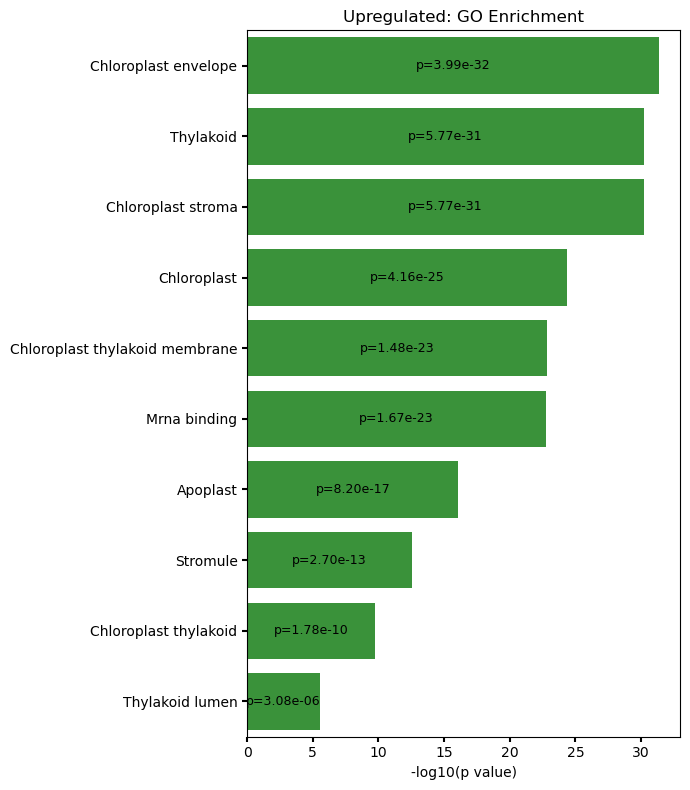

In [65]:
top_n_terms = 10

plot_up = up_go_named.dropna(subset=["x"]).head(top_n_terms).copy()
plot_up["x"] = plot_up["x"].str.capitalize()

fig, ax = plt.subplots(1, 1, figsize=(7, 8))
fig.patch.set_facecolor("white")

if len(plot_up) > 0:
    g = sns.barplot(data=plot_up, x="Neg Log P Val", y="x", color="tab:green", ax=ax)

    # Put p-value labels directly on bars, similar to the earlier GO plot style.
    p_value_labels = [f"p={p_val:.2e}" for p_val in plot_up["P_value"].fillna(np.nan)]
    g.bar_label(g.containers[0], labels=p_value_labels, label_type="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No enriched terms", ha="center", va="center")

ax.set_title("Upregulated: GO Enrichment")
ax.set_xlabel("-log10(p value)")
ax.set_ylabel("")
ax.grid(False)

ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["top"].set_color("black")
ax.spines["right"].set_color("black")
ax.tick_params(axis="both", width=1.5)

plt.tight_layout()